# Bank churn — merged pipeline

## Business context (from project plan)

Banks lose revenue when customers **churn**; keeping an existing customer is usually cheaper than acquiring a new one. This notebook supports **early identification** of customers likely to leave so the bank can target retention (offers, service changes, etc.).

**Goal:** predict **who will leave** (binary churn).

**Outcomes we target:** (1) a churn score / class, (2) **evaluation** of models on held-out data, and (3) **insight** into which customer attributes align with higher churn risk—not just accuracy for its own sake.

## Why these four models?

We follow a deliberate progression:

1. **Logistic regression** — interpretable **coefficients**: which features push predicted churn up or down?
2. **Neural network (MLP)** — can **nonlinear** interactions beat the linear baseline on the same scaled inputs?
3. **Decision tree** — **if–then rules** and importances: what decision patterns separate churners from stayers?
4. **KNN** — **similarity**: do customers with comparable profiles (after scaling) tend to share the same outcome? *k* is chosen by cross-validation on the training set.

Together: **simple → more flexible → interpretable rules → instance-based comparison.**

## This notebook

Single end-to-end workflow: preparation, exploratory views, one stratified train/test split, then the four models above.

**Data:** `BankChurners.csv` — we drop the ID column and model-leakage `Naive_Bayes_*` columns, encode the target, one-hot encode categoricals, and use `StandardScaler` for models that rely on distances or linear geometry (logistic regression, MLP, KNN). The decision tree is fit on **unscaled** features so thresholds stay in original units for interpretation.


In [31]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc,
)


## Load and clean

- Drop `CLIENTNUM` (identifier).
- Drop `Naive_Bayes_Classifier...` columns (leakage from another model).
- Target: `Existing Customer` = 0, `Attrited Customer` = 1.


In [32]:
df = pd.read_csv("BankChurners.csv")

drop_cols = ["CLIENTNUM"] + [c for c in df.columns if c.startswith("Naive_Bayes_Classifier")]
df = df.drop(columns=drop_cols)

df["Attrition_Flag"] = df["Attrition_Flag"].map({
    "Existing Customer": 0,
    "Attrited Customer": 1,
})

df.head()


,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,0,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,0,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,0,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,0,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,0,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


## Exploratory plots

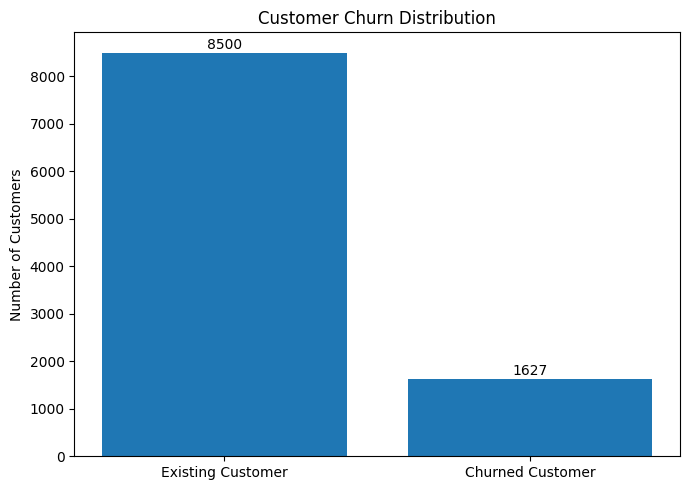

Churn rate: 16.07%


In [33]:
churn_counts = df["Attrition_Flag"].value_counts().sort_index()
labels = ["Existing Customer", "Churned Customer"]

plt.figure(figsize=(7, 5))
plt.bar(labels, churn_counts.values)
plt.title("Customer Churn Distribution")
plt.ylabel("Number of Customers")
for i, v in enumerate(churn_counts.values):
    plt.text(i, v + 80, str(v), ha="center")
plt.tight_layout()
plt.show()

print(f"Churn rate: {df['Attrition_Flag'].mean() * 100:.2f}%")


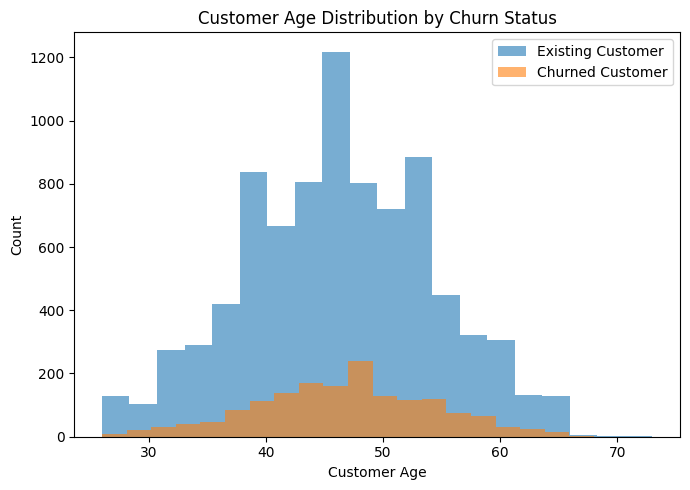

In [34]:
plt.figure(figsize=(7, 5))
for target_value, label in [(0, "Existing Customer"), (1, "Churned Customer")]:
    plt.hist(
        df.loc[df["Attrition_Flag"] == target_value, "Customer_Age"],
        bins=20,
        alpha=0.6,
        label=label,
    )
plt.title("Customer Age Distribution by Churn Status")
plt.xlabel("Customer Age")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


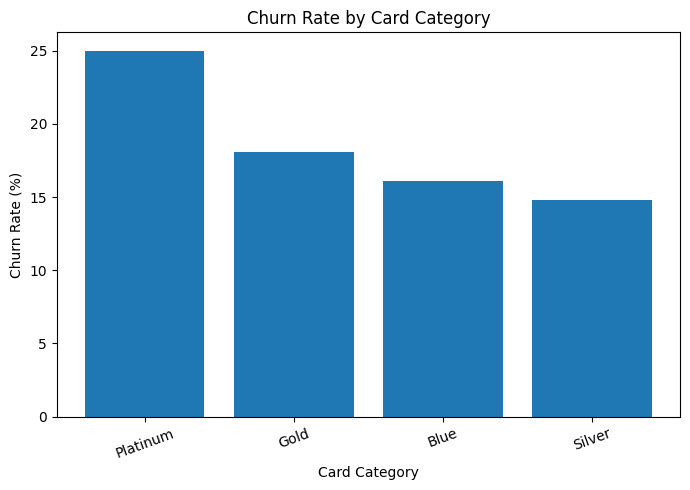

,Churn Rate (%)
Card_Category,
Platinum,25.000000
Gold,18.103448
Blue,16.097923
Silver,14.774775


In [35]:
card_churn = (
    df.groupby("Card_Category")["Attrition_Flag"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

plt.figure(figsize=(7, 5))
plt.bar(card_churn.index, card_churn.values)
plt.title("Churn Rate by Card Category")
plt.xlabel("Card Category")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

card_churn.to_frame(name="Churn Rate (%)")


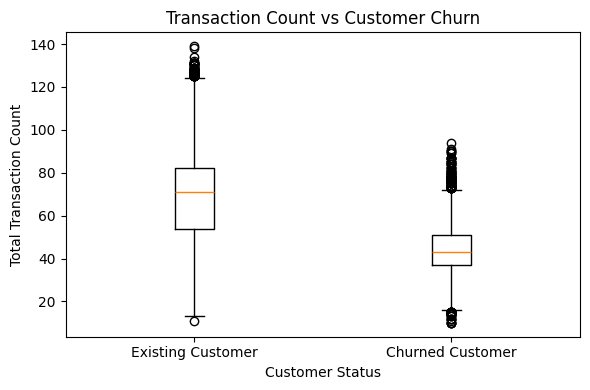

In [36]:
existing = df[df["Attrition_Flag"] == 0]["Total_Trans_Ct"]
churned = df[df["Attrition_Flag"] == 1]["Total_Trans_Ct"]

plt.figure(figsize=(6, 4))
plt.boxplot([existing, churned], labels=["Existing Customer", "Churned Customer"])
plt.title("Transaction Count vs Customer Churn")
plt.xlabel("Customer Status")
plt.ylabel("Total Transaction Count")
plt.tight_layout()
plt.show()


## Train / test split and scaling

Categorical columns are one-hot encoded (`drop_first=True`). Same split as the original notebooks: 80/20, `random_state=42`, stratified on `y`.

**Scaled** matrices are used for logistic regression, MLP, and KNN. The **decision tree** is fit on **unscaled** `X_train` / evaluated on `X_test` (same as the decision-tree notebook) so splits stay in original feature units for interpretation.


In [37]:
X = df.drop(columns=["Attrition_Flag"])
y = df["Attrition_Flag"]
X = pd.get_dummies(X, drop_first=True)

print("Feature matrix shape:", X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Feature matrix shape: (10127, 32)


## 1. Logistic Regression

In [38]:
log_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42,
)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

log_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_log),
    "Precision": precision_score(y_test, y_pred_log),
    "Recall": recall_score(y_test, y_pred_log),
    "F1 Score": f1_score(y_test, y_pred_log),
}
pd.DataFrame(log_metrics, index=["Logistic Regression"]).T


,Logistic Regression
Accuracy,0.854886
Precision,0.530938
Recall,0.818462
F1 Score,0.644068


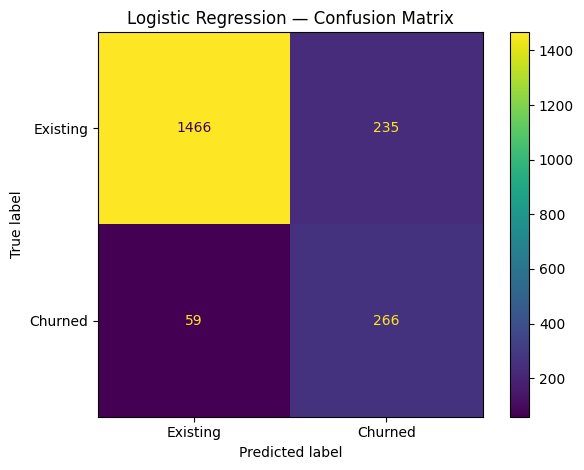

In [39]:
cm_log = confusion_matrix(y_test, y_pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=["Existing", "Churned"])
disp.plot()
plt.title("Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.show()


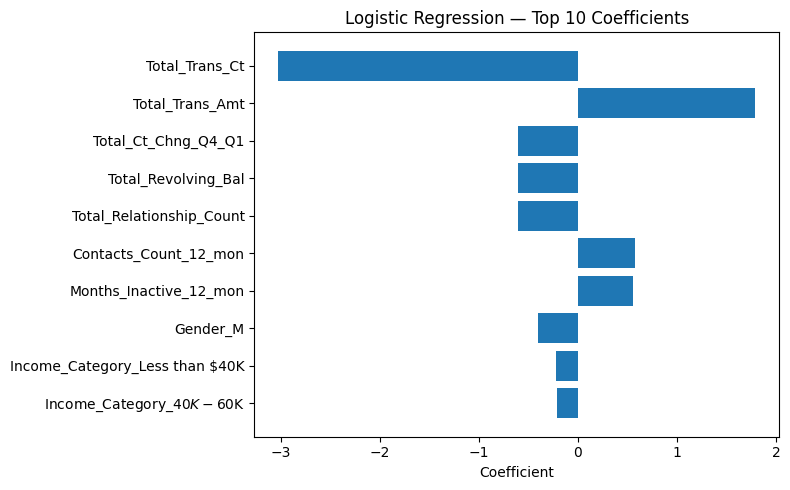

,Feature,Coefficient
11,Total_Trans_Ct,-3.024478
10,Total_Trans_Amt,1.790733
12,Total_Ct_Chng_Q4_Q1,-0.606237
7,Total_Revolving_Bal,-0.604718
3,Total_Relationship_Count,-0.601669
5,Contacts_Count_12_mon,0.579679
4,Months_Inactive_12_mon,0.557786
14,Gender_M,-0.402141
27,Income_Category_Less than $40K,-0.226488
24,Income_Category_$40K - $60K,-0.214332


In [40]:
coef_df = pd.DataFrame({"Feature": X.columns, "Coefficient": log_model.coef_[0]})
coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()
top10_coef = coef_df.sort_values("Abs_Coefficient", ascending=False).head(10)

plt.figure(figsize=(8, 5))
plt.barh(top10_coef["Feature"][::-1], top10_coef["Coefficient"][::-1])
plt.title("Logistic Regression — Top 10 Coefficients")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

top10_coef[["Feature", "Coefficient"]]


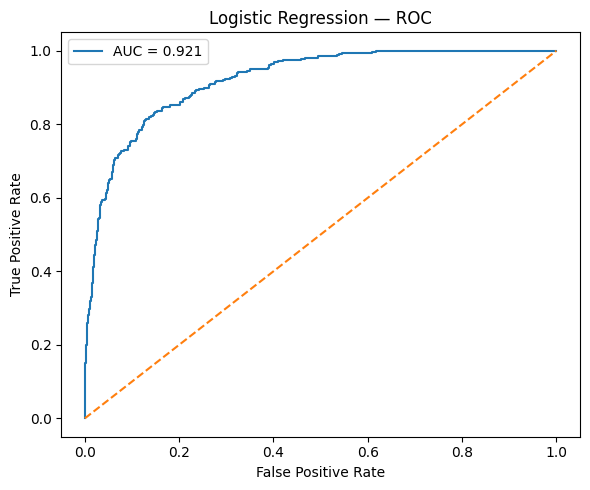

In [41]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
auc_log = auc(fpr_log, tpr_log)

plt.figure(figsize=(6, 5))
plt.plot(fpr_log, tpr_log, label=f"AUC = {auc_log:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Logistic Regression — ROC")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()


## 2. Neural Network (MLP)

Small two-hidden-layer MLP on scaled inputs. `sample_weight` uses the balanced scheme to reflect class imbalance (MLP has no `class_weight` argument).


In [42]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
)
sample_w = compute_sample_weight("balanced", y_train)
mlp.fit(X_train_scaled, y_train, sample_weight=sample_w)

y_pred_mlp = mlp.predict(X_test_scaled)

mlp_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_mlp),
    "Precision": precision_score(y_test, y_pred_mlp),
    "Recall": recall_score(y_test, y_pred_mlp),
    "F1 Score": f1_score(y_test, y_pred_mlp),
}
pd.DataFrame(mlp_metrics, index=["MLP (Neural Network)"]).T


,MLP (Neural Network)
Accuracy,0.907206
Precision,0.661939
Recall,0.861538
F1 Score,0.748663


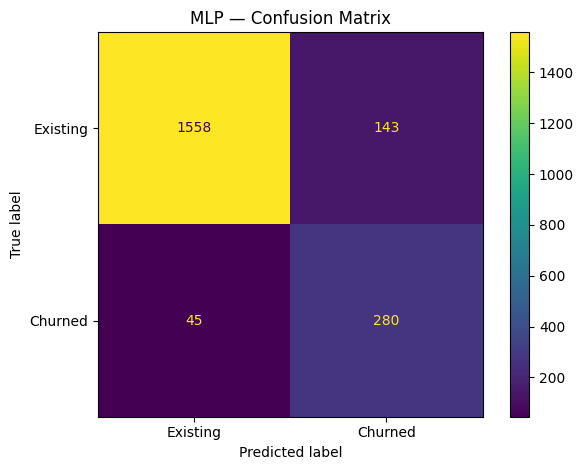

In [43]:
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
ConfusionMatrixDisplay(cm_mlp, display_labels=["Existing", "Churned"]).plot()
plt.title("MLP — Confusion Matrix")
plt.tight_layout()
plt.show()


## 3. Decision Tree (tuned with grid search, unscaled features)

In [44]:
params = {
    "max_depth": [3, 4, 5, 6],
    "min_samples_split": [2, 5, 10],
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    params,
    cv=5,
    scoring="f1",
)
grid.fit(X_train, y_train)
best_dt = grid.best_estimator_
print("Best parameters:", grid.best_params_)


Best parameters: {'max_depth': 6, 'min_samples_split': 2}


In [45]:
y_pred_dt = best_dt.predict(X_test)

dt_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_dt),
    "Precision": precision_score(y_test, y_pred_dt),
    "Recall": recall_score(y_test, y_pred_dt),
    "F1 Score": f1_score(y_test, y_pred_dt),
}
pd.DataFrame(dt_metrics, index=["Decision Tree"]).T


,Decision Tree
Accuracy,0.904245
Precision,0.646532
Recall,0.889231
F1 Score,0.748705


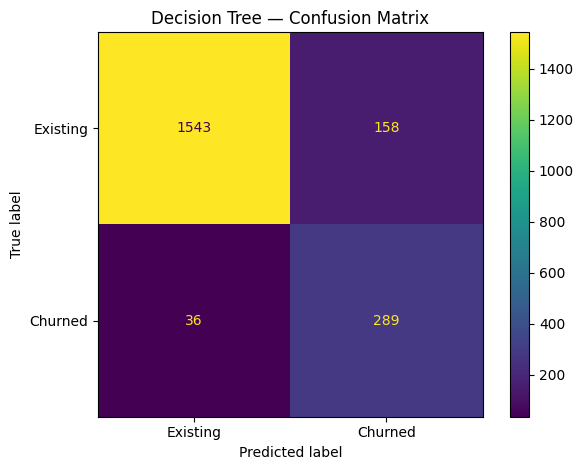

In [46]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=["Existing", "Churned"],
).plot(values_format="d")
plt.title("Decision Tree — Confusion Matrix")
plt.tight_layout()
plt.show()


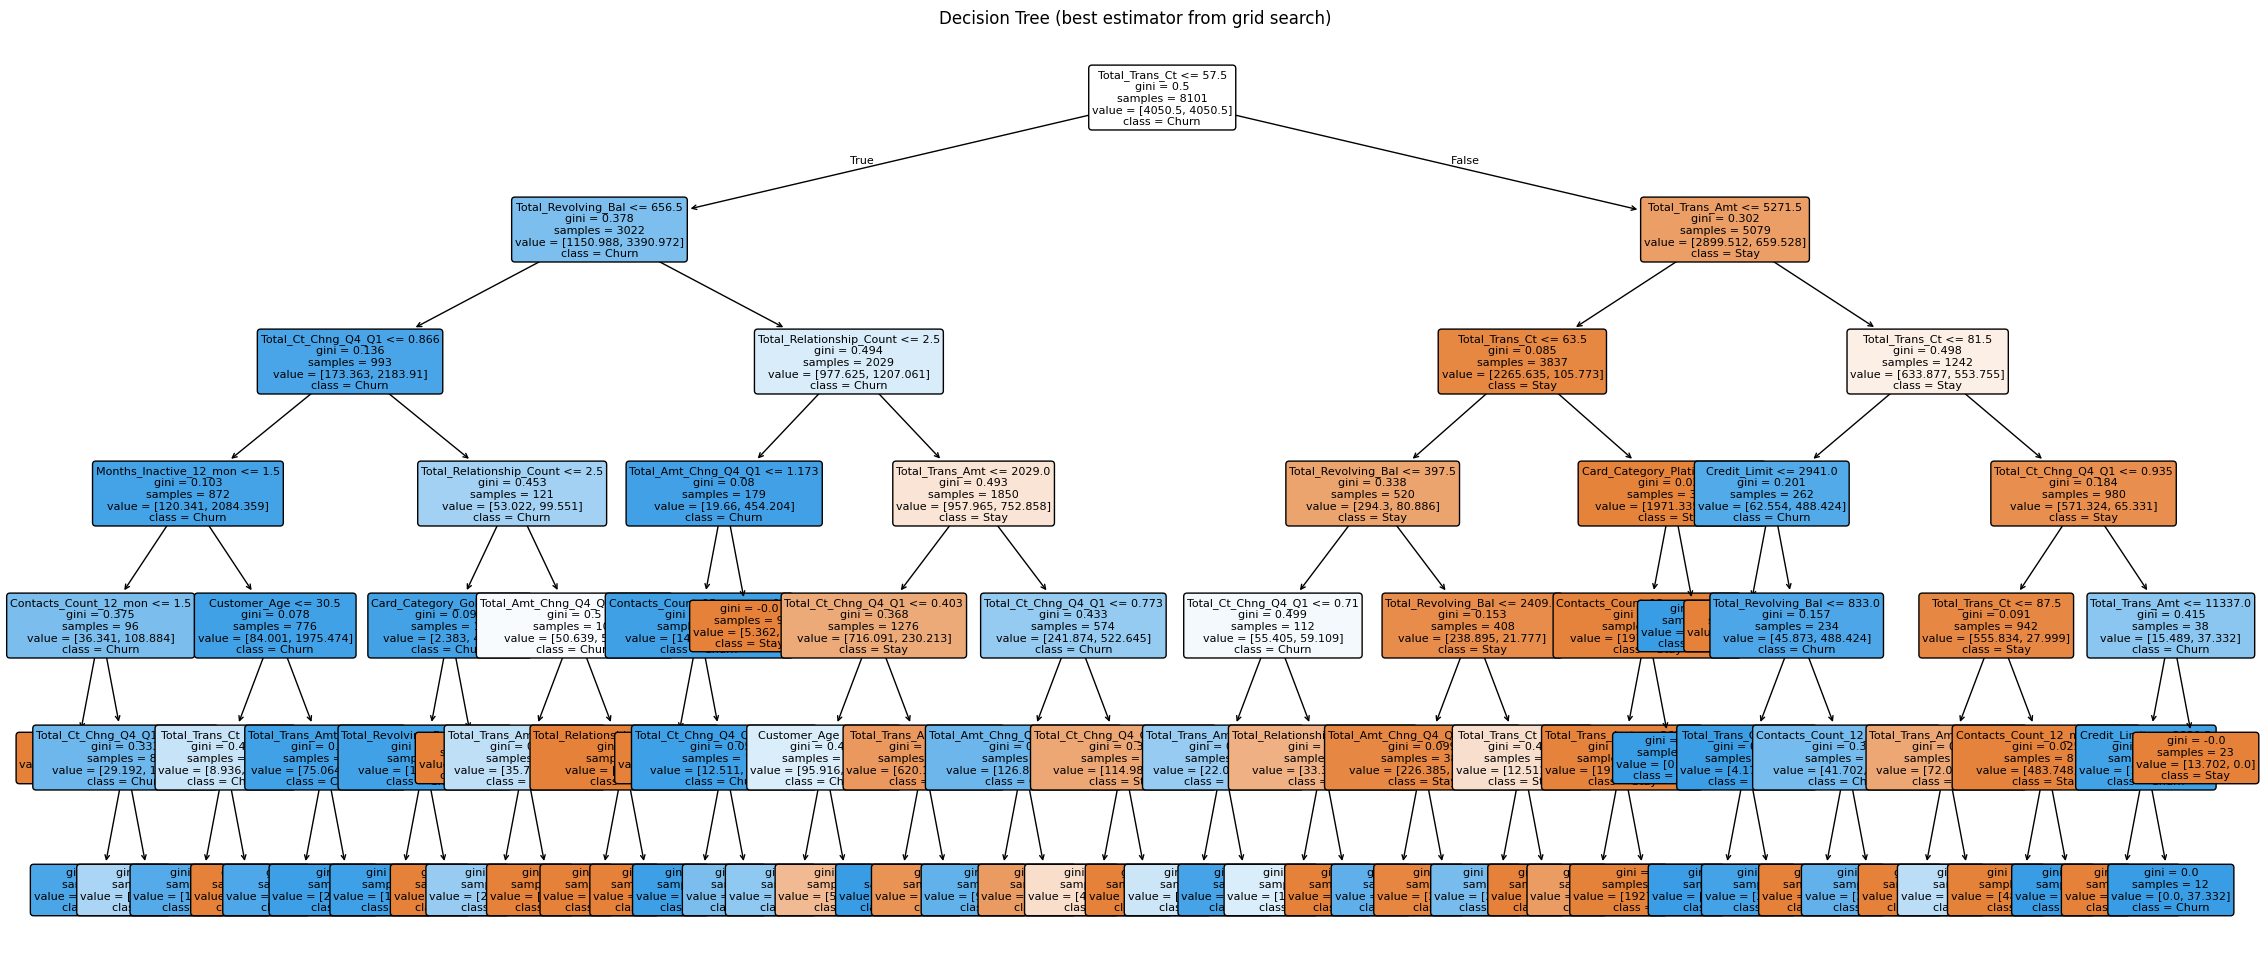

In [47]:
plt.figure(figsize=(28, 12))
plot_tree(
    best_dt,
    feature_names=X.columns,
    class_names=["Stay", "Churn"],
    filled=True,
    rounded=True,
    fontsize=8,
)
plt.title("Decision Tree (best estimator from grid search)")
plt.show()


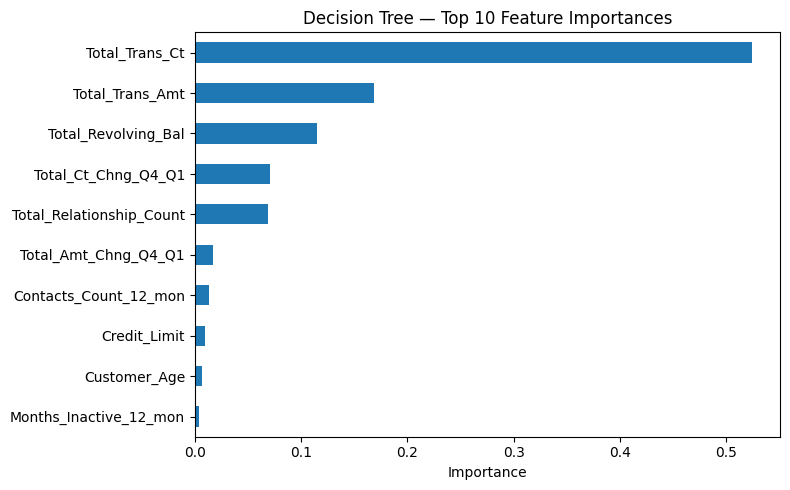

Total_Trans_Ct              0.524448
Total_Trans_Amt             0.168689
Total_Revolving_Bal         0.114902
Total_Ct_Chng_Q4_Q1         0.070947
Total_Relationship_Count    0.068994
Total_Amt_Chng_Q4_Q1        0.016735
Contacts_Count_12_mon       0.013041
Credit_Limit                0.009576
Customer_Age                0.006670
Months_Inactive_12_mon      0.003743
dtype: float64

In [48]:
dt_importance = pd.Series(best_dt.feature_importances_, index=X.columns)
dt_top = dt_importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
dt_top.sort_values().plot(kind="barh")
plt.title("Decision Tree — Top 10 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

dt_top


## 4. KNN (scaled features)

KNN uses distances between customers, so we train and evaluate on **scaled** features (`StandardScaler` above).

**Choosing $k$:** We do not pick a fixed $k$ without evidence. For each $k \in \{1,\ldots,20\}$, we run **5-fold cross-validation on the training set only**, record the **mean validation accuracy**, and choose the $k$ with the best mean score. We then **refit on the full training set** with that $k$ and evaluate on the **held-out test** set. The next cell plots mean CV accuracy vs. $k$ so the choice is visible.

*Note:* Accuracy can overweight the majority (non-churn) class. If you care more about catching churn, repeat the search with `scoring="f1"` instead.

We use `weights="distance"` so closer neighbors influence the vote more.

Best k (max mean 5-fold CV accuracy on training): k = 10
Mean CV accuracy at best k: 0.8767


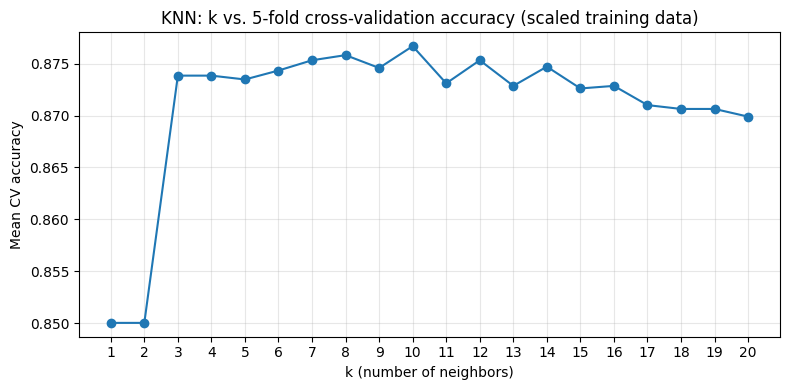

,KNN (k=10)
Accuracy,0.872655
Precision,0.831683
Recall,0.258462
F1 Score,0.394366


In [50]:
k_range = list(range(1, 21))
cv_mean_acc = []

for k in k_range:
    knn_cv = KNeighborsClassifier(n_neighbors=k, weights="distance")
    scores = cross_val_score(
        knn_cv, X_train_scaled, y_train, cv=5, scoring="accuracy"
    )
    cv_mean_acc.append(scores.mean())

best_k = k_range[int(np.argmax(cv_mean_acc))]
print(f"Best k (max mean 5-fold CV accuracy on training): k = {best_k}")
print(f"Mean CV accuracy at best k: {max(cv_mean_acc):.4f}")

plt.figure(figsize=(8, 4))
plt.plot(k_range, cv_mean_acc, marker="o")
plt.xlabel("k (number of neighbors)")
plt.ylabel("Mean CV accuracy")
plt.title("KNN: k vs. 5-fold cross-validation accuracy (scaled training data)")
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

knn = KNeighborsClassifier(n_neighbors=best_k, weights="distance")
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

knn_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_knn),
    "Precision": precision_score(y_test, y_pred_knn),
    "Recall": recall_score(y_test, y_pred_knn),
    "F1 Score": f1_score(y_test, y_pred_knn),
}
pd.DataFrame(knn_metrics, index=[f"KNN (k={best_k})"]).T


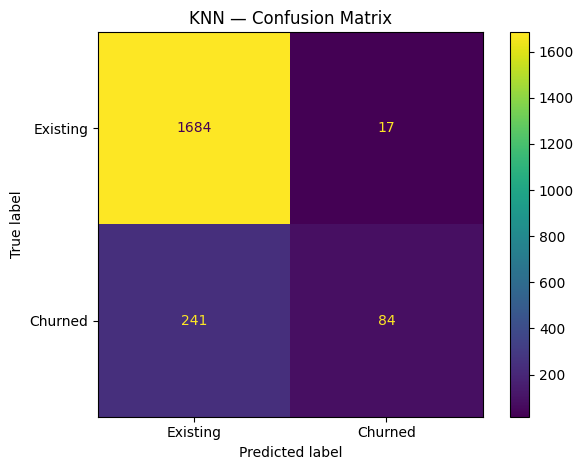

In [51]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
ConfusionMatrixDisplay(cm_knn, display_labels=["Existing", "Churned"]).plot()
plt.title("KNN — Confusion Matrix")
plt.tight_layout()
plt.show()


## Test-set metric comparison

In [52]:
summary = pd.DataFrame(
    [log_metrics, mlp_metrics, dt_metrics, knn_metrics],
    index=["Logistic Regression", "MLP", "Decision Tree", f"KNN (k={best_k})"],
)
summary.round(4)


,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.8549,0.5309,0.8185,0.6441
MLP,0.9072,0.6619,0.8615,0.7487
Decision Tree,0.9042,0.6465,0.8892,0.7487
KNN (k=10),0.8727,0.8317,0.2585,0.3944


## Interpretation and takeaways

### Reading the test-set summary

Use the comparison table above together with the confusion matrices. **Accuracy** can look high even when churn (the minority class) is predicted poorly, so also compare **precision, recall, and F1** for the churn class. Your business priority should drive which metric matters most (e.g. high **recall** if missing a churner is costly, high **precision** if interventions are expensive).

### What drives churn?

- **Logistic regression**: The bar chart of coefficient magnitudes shows which engineered features (after one-hot encoding) move the **log-odds** of churn in each direction. Signs and sizes are easy to narrate to a non-technical audience, with the usual caveat that coefficients reflect **association**, not proven causation.
- **Decision tree**: **Feature importances** and the tree diagram summarize overlapping information in rule form (e.g. paths dominated by engagement or balance-related splits). When the tree’s top variables agree with large logistic coefficients, you have a stronger story for “what to watch” operationally.

### Which model for which question?

| Need | Model to emphasize |
|------|---------------------|
| Transparent linear effects, compliance-friendly | **Logistic regression** |
| Stronger fit if patterns are nonlinear | **MLP** (harder to explain per feature) |
| Explicit **if–then** stories for branches or campaigns | **Decision tree** |
| “Customers like this one” / neighborhood reasoning | **KNN** (with *k* from CV) |

### Limitations and next steps

- Metrics are from **one** stratified split (`random_state=42`); rankings could move slightly with another seed or with **k-fold evaluation across all models** on the same folds.
- Models are **associative**; intervention decisions should still use domain knowledge and policy constraints.
- Optional extensions: tune or compare models with **F1 or cost-sensitive** scoring aligned to churn prevalence; **calibration** of predicted probabilities for risk ranking; or **SHAP** for richer post-hoc explanations beyond the tree alone.
